In [ ]:
!pip install xport

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 42.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [3]:

from google.colab import drive

# 1. Mount Google Drive to access your files
drive.mount('/content/drive')

# Define the exact path where your NHANES files are stored
# Based on your screenshot, they are in a folder named 'NHANES' in your root Drive directory
FOLDER_PATH = '/content/drive/MyDrive/NHANES/'

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# List of files you successfully downloaded
nhanes_files = [
    'DEMO_L.xpt',   # Demographics (Must be first to establish base matrix)
    'TRIGLY_L.xpt', # LDL & Triglycerides
    'SMQ_L.xpt',    # Smoking Habits
    'HDL_L.xpt',    # HDL Cholesterol
    'GHB_L.xpt',    # Glycohemoglobin (HbA1c)
    'BPXO_L.xpt',   # Blood Pressure
    'BPQ_L.xpt',    # Blood Pressure History
    'BMX_L.xpt',    # Body Measures
    'BIOPRO_L.xpt'  # Biochemistry Profile
]

def load_and_merge_nhanes(folder, files_list):
    """
    High-speed merge pipeline: reads binary XPT files sequentially
    and performs a deterministic relational outer join on index 'SEQN'.
    """
    merged_df = None

    for file_name in files_list:
        full_path = os.path.join(folder, file_name)
        if not os.path.exists(full_path):
            # Check case-sensitivity backup if file extension differs
            full_path = os.path.join(folder, file_name.replace('.xpt', '.XPT'))

        print(f"Parsing binary stream: {os.path.basename(full_path)}...")

        # read_sas is optimized natively via underlying C engine code
        df = pd.read_sas(full_path, format='xport')

        # Ensure SEQN is typed uniformly across separate extractions
        df['SEQN'] = df['SEQN'].astype(int)

        if merged_df is None:
            merged_df = df
        else:
            # Relational outer join keeps rows even if minor missing data occurs across labs
            merged_df = pd.merge(merged_df, df, on='SEQN', how='outer')

    return merged_df

# Run the merge sequence
raw_features_df = load_and_merge_nhanes(FOLDER_PATH, nhanes_files)
print(f"\nSuccessfully created flat dataset table. Shape: {raw_features_df.shape}")

# --- High Performance Processing for PyTorch Tensor Conversions ---

# Handle missing data (NaN) values common in NHANES clinical tables
# PyTorch tensors require full matrices without NaN slots.
# Here we fill with standard column medians for numeric stability.
# --- Robust Preprocessing Pipeline for PyTorch Tensor Stability ---

processed_df = raw_features_df.copy()

# 1. Decode byte strings if any exist (common when pandas reads SAS binary files)
for col in processed_df.columns:
    if processed_df[col].dtype == object:
        # Convert raw binary bytes into standard Python strings
        processed_df[col] = processed_df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

print("Handling missing values and encoding categorical text features...")

# 2. Dynamically clean and impute based on column data type
for col in processed_df.columns:
    if col == 'SEQN':
        continue

    # Check if the column is strictly numerical
    if pd.api.types.is_numeric_dtype(processed_df[col]):
        # Safely fill numeric NaNs with the column median
        col_median = processed_df[col].median()
        # If the whole column is NaN, fill with 0 to prevent downstream breaks
        processed_df[col] = processed_df[col].fillna(col_median if not pd.isna(col_median) else 0)

    else:
        # It's a text/string column (like the one containing b'R')
        print(f"-> Categorical text column detected: '{col}'")
        # Fill missing text with a placeholder string
        processed_df[col] = processed_df[col].fillna('Missing')
        # Convert strings to numeric categories (0, 1, 2, etc.) using category codes
        processed_df[col] = processed_df[col].astype('category').cat.codes

# 3. Separate index identity from structural input features
feature_columns = [col for col in processed_df.columns if col != 'SEQN']
X_data = processed_df[feature_columns].values

# --- Implement Custom PyTorch Dataset Wrapper ---
class NHANESDataset(Dataset):
    def __init__(self, features_matrix):
        # Everything is now cleanly numerical, ready for fast FloatTensor compilation
        self.features = torch.tensor(features_matrix, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx]

# Instantiate the PyTorch Dataset
nhanes_pytorch_dataset = NHANESDataset(X_data)
print(f"\nSuccess! PyTorch Dataset built with shape: {X_data.shape}")

# Example DataLoader implementation
data_loader = DataLoader(nhanes_pytorch_dataset, batch_size=64, shuffle=True)
print("DataLoader initialized smoothly. Ready for model training updates.")

Parsing binary stream: DEMO_L.xpt...
Parsing binary stream: TRIGLY_L.xpt...
Parsing binary stream: SMQ_L.xpt...
Parsing binary stream: HDL_L.xpt...
Parsing binary stream: GHB_L.xpt...
Parsing binary stream: BPXO_L.xpt...
Parsing binary stream: BPQ_L.xpt...
Parsing binary stream: BMX_L.xpt...
Parsing binary stream: BIOPRO_L.xpt...

Successfully created flat dataset table. Shape: (11933, 127)
Handling missing values and encoding categorical text features...
-> Categorical text column detected: 'BPAOARM'

Success! PyTorch Dataset built with shape: (11933, 126)
DataLoader initialized smoothly. Ready for model training updates.


In [ ]:
# Save the clean dataframe as a standard CSV file directly in your Drive folder
output_path = os.path.join(FOLDER_PATH, 'nhanes_cleaned_dataset.csv')
processed_df.to_csv(output_path, index=False)

print(f"File permanently stored at: {output_path}")

File permanently stored at: /content/drive/MyDrive/NHANES/nhanes_cleaned_dataset.csv


In [ ]:
# 30/05/26

In [ ]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Access your storage
drive.mount('/content/drive')
FOLDER_PATH = '/content/drive/MyDrive/NHANES/'
input_file = os.path.join(FOLDER_PATH, 'nhanes_cleaned_dataset.csv')

# Load your combined NHANES dataset
print("Loading clean NHANES dataset...")
df_nhanes = pd.read_csv(input_file)

# 2. Structural Column Translations (NHANES Codes -> MIMIC Names)
# We map the exact matching biometric data columns here
mapping_dict = {
    'SEQN': 'subject_id',          # Map unique identifier sequence to subject_id
    'RIDAGEYR': 'anchor_age',      # Literal age in years
    'BMXTEMP': 'vital_mean_temp',  # Body temperature
    'BMXWT': 'vital_mean_weight'   # Weight tracking variable if needed
}

df_mimic_style = df_nhanes.rename(columns=mapping_dict).copy()

# 3. Handle Demographics / Categorical Alignments
# In your MIMIC dataset, gender is represented by 'is_male' (1 = Male, 0 = Female)
# In NHANES, RIAGENDR is coded as: 1 = Male, 2 = Female. Let's align this perfectly:
if 'RIAGENDR' in df_mimic_style.columns:
    df_mimic_style['is_male'] = df_mimic_style['RIAGENDR'].apply(lambda x: 1 if x == 1 else 0)
else:
    # Fallback placeholder if column name variant exists
    df_mimic_style['is_male'] = 0

# 4. Map and Calculate Vital Sign Metrics
# MIMIC uses average vitals. We will average the automated NHANES blood pressure readings.
sbp_cols = ['BPXOSY1', 'BPXOSY2', 'BPXOSY3']
dbp_cols = ['BPXODI1', 'BPXODI2', 'BPXODI3']

# Filter out available columns to prevent errors if one cycle run missed an iteration
valid_sbp = [c for c in sbp_cols if c in df_mimic_style.columns]
valid_dbp = [c for c in dbp_cols if c in df_mimic_style.columns]

if valid_sbp:
    df_mimic_style['vital_mean_systolic_bp'] = df_mimic_style[valid_sbp].mean(axis=1)
else:
    df_mimic_style['vital_mean_systolic_bp'] = np.nan

if valid_dbp:
    df_mimic_style['vital_mean_diastolic_bp'] = df_mimic_style[valid_dbp].mean(axis=1)
else:
    df_mimic_style['vital_mean_diastolic_bp'] = np.nan

# 5. Create Placeholders for Missing MIMIC Text Features
# Your cross-validation model requires identical column shapes. We populate
# the text-mined NLP features not present in structural labs with neutral baseline zeros (0).
mimic_nlp_features = [
    'report_1st', 'report_1st_degree', 'report_abnormal', 'report_abnormal_ecg',
    'report_anterior', 'report_atrial', 'report_atrial_fibrillation', 'report_axis',
    'report_block', 'report_borderline', 'report_changes', 'report_changes_myocardial',
    'report_changes_nonspecific', 'report_degree', 'report_degree_block', 'report_deviation',
    'report_ecg', 'report_ecg_sinus', 'report_extensive', 'report_fibrillation',
    'report_hypertrophy', 'report_infarct', 'report_infarct_age', 'report_inferior',
    'report_inferior_infarct', 'report_inferior_lateral', 'report_ischemia', 'report_lateral',
    'report_lateral_st', 'report_leads', 'report_left', 'report_myocardial',
    'report_myocardial_ischemia', 'report_nonspecific', 'report_possible', 'report_response',
    'report_rhythm', 'report_sinus', 'report_sinus_rhythm', 'report_st', 'report_st_changes',
    'title_angioplasty', 'title_approach', 'title_arteriography', 'title_arteriography_using',
    'title_artery', 'title_cardiac', 'title_cardiac_catheterization', 'title_catheterization',
    'title_catheters', 'title_coronary', 'title_coronary_arteriography', 'title_coronary_artery',
    'title_drug', 'title_drug_eluting', 'title_eluting', 'title_heart', 'title_heart_cardiac',
    'title_insertion', 'title_left', 'title_left_heart', 'title_percutaneous',
    'title_percutaneous_approach', 'title_procedure', 'title_right', 'title_single',
    'title_stent', 'title_transluminal', 'title_transluminal_coronary', 'title_using',
    'title_using_catheters', 'vital_mean_heart_rate', 'vital_mean_spo2'
]

for feature in mimic_nlp_features:
    df_mimic_style[feature] = 0.0

# 6. Final Core Clean Up and Column Alignment Ordering
# Target columns we want to preserve to mirror your screenshot layout
target_order = [
    'subject_id', 'anchor_age', 'is_male', 'vital_mean_systolic_bp',
    'vital_mean_diastolic_bp', 'vital_mean_temp'
] + mimic_nlp_features

# Ensure we fill any newly generated metric NaNs to secure PyTorch compatibility
for core_col in ['vital_mean_systolic_bp', 'vital_mean_diastolic_bp', 'vital_mean_temp']:
    if core_col in df_mimic_style.columns:
        df_mimic_style[core_col] = df_mimic_style[core_col].fillna(df_mimic_style[core_col].median())

# Select only the features that are shared with your MIMIC setup
final_cross_val_df = df_mimic_style[[col for col in target_order if col in df_mimic_style.columns]]

# 7. Save Dataset back to your Google Drive folder
output_file = os.path.join(FOLDER_PATH, 'nhanes_to_mimic_crossval.csv')
final_cross_val_df.to_csv(output_file, index=False)

print(f"\nAlignment Complete! Matrix Shape: {final_cross_val_df.shape}")
print(f"Cross-validation file successfully stored at: {output_file}")
print("\nPreview of aligned NHANES data columns:")
print(final_cross_val_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading clean NHANES dataset...

Alignment Complete! Matrix Shape: (11933, 78)
Cross-validation file successfully stored at: /content/drive/MyDrive/NHANES/nhanes_to_mimic_crossval.csv

Preview of aligned NHANES data columns:
   subject_id  anchor_age  is_male  vital_mean_systolic_bp  \
0      130378        43.0        1              132.666667   
1      130379        66.0        1              117.000000   
2      130380        44.0        0              109.000000   
3      130381         5.0        0              116.333333   
4      130382         2.0        1              116.333333   

   vital_mean_diastolic_bp  report_1st  report_1st_degree  report_abnormal  \
0                96.000000         0.0                0.0              0.0   
1                78.666667         0.0                0.0              0.0   
2                78.333333         0.0 

In [ ]:
final_cross_val_df.isnull().sum()

,0
subject_id,0
anchor_age,0
is_male,0
vital_mean_systolic_bp,0
vital_mean_diastolic_bp,0
...,...
title_transluminal_coronary,0
title_using,0
title_using_catheters,0
vital_mean_heart_rate,0


In [ ]:
final_cross_val_df.sample(12)

,subject_id,anchor_age,is_male,vital_mean_systolic_bp,vital_mean_diastolic_bp,report_1st,report_1st_degree,report_abnormal,report_abnormal_ecg,report_anterior,...,title_procedure,title_right,title_single,title_stent,title_transluminal,title_transluminal_coronary,title_using,title_using_catheters,vital_mean_heart_rate,vital_mean_spo2
6007,136385,63.0,1,138.666667,62.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3497,133875,71.0,1,112.000000,62.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
310,130688,72.0,0,143.666667,80.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3938,134316,60.0,1,130.666667,79.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8111,138489,41.0,1,116.666667,90.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1888,132266,2.0,1,116.333333,71.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7176,137554,67.0,1,116.333333,71.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6162,136540,21.0,0,100.666667,55.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4874,135252,66.0,0,116.333333,71.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9402,139780,72.0,1,110.333333,66.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

# Mount storage
drive.mount('/content/drive')
FOLDER_PATH = '/content/drive/MyDrive/NHANES/'

# Load the true NHANES data you generated
df_nhanes = pd.read_csv(os.path.join(FOLDER_PATH, 'nhanes_cleaned_dataset.csv'))

# Create a clean dataframe for the shared features
aligned_nhanes = pd.DataFrame()

# 1. Map Subject Identifier
aligned_nhanes['subject_id'] = df_nhanes['SEQN'].astype(int)

# 2. Map Demographics
if 'RIDAGEYR' in df_nhanes.columns:
    aligned_nhanes['anchor_age'] = df_nhanes['RIDAGEYR']

if 'RIAGENDR' in df_nhanes.columns:
    # Convert NHANES (1=Male, 2=Female) to MIMIC binary (1=Male, 0=Female)
    aligned_nhanes['is_male'] = df_nhanes['RIAGENDR'].apply(lambda x: 1 if x == 1 else 0)

# 3. Map Vital Signs (Averaging the NHANES blood pressure readings safely)
sbp_cols = [c for c in ['BPXOSY1', 'BPXOSY2', 'BPXOSY3'] if c in df_nhanes.columns]
dbp_cols = [c for c in ['BPXODI1', 'BPXODI2', 'BPXODI3'] if c in df_nhanes.columns]

if sbp_cols:
    aligned_nhanes['vital_mean_systolic_bp'] = df_nhanes[sbp_cols].mean(axis=1)
if dbp_cols:
    aligned_nhanes['vital_mean_diastolic_bp'] = df_nhanes[dbp_cols].mean(axis=1)

# 4. Handle Missing Values using true local medians
for col in aligned_nhanes.columns:
    if col != 'subject_id':
        aligned_nhanes[col] = aligned_nhanes[col].fillna(aligned_nhanes[col].median())

# Save the honest, aligned dataset
output_path = os.path.join(FOLDER_PATH, 'nhanes_shared_features.csv')
aligned_nhanes.to_csv(output_path, index=False)

print(f"Alignment complete! Shared feature matrix shape: {aligned_nhanes.shape}")
print("Columns preserved for cross-validation:", list(aligned_nhanes.columns))
print(aligned_nhanes.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Alignment complete! Shared feature matrix shape: (11933, 5)
Columns preserved for cross-validation: ['subject_id', 'anchor_age', 'is_male', 'vital_mean_systolic_bp', 'vital_mean_diastolic_bp']
   subject_id  anchor_age  is_male  vital_mean_systolic_bp  \
0      130378        43.0        1              132.666667   
1      130379        66.0        1              117.000000   
2      130380        44.0        0              109.000000   
3      130381         5.0        0              116.333333   
4      130382         2.0        1              116.333333   

   vital_mean_diastolic_bp  
0                96.000000  
1                78.666667  
2                78.333333  
3                71.333333  
4                71.333333  


In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# --- 1. Load the Mapped Shared Dataset ---
# Ensure your drive is mounted and path matches your generated file
filepath = '/content/drive/MyDrive/NHANES/nhanes_shared_features.csv'
df_shared = pd.read_csv(filepath)

# --- 2. Separate Features from Identity Keys ---
# Drop the ID column so the neural network doesn't try to learn patterns from sequence numbers
feature_cols = [col for col in df_shared.columns if col != 'subject_id']
X_raw = df_shared[feature_cols].values

# --- 3. High Performance Feature Scaling ---
# Neural networks struggle when Age (0-80) and Blood Pressure (90-180) are on massive, raw scales.
# This shifts features to have a mean of 0 and variance of 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# --- 4. Deep Learning PyTorch Dataset ---
class PyTorchSharedDataset(Dataset):
    def __init__(self, x_matrix):
        # Pack into optimized PyTorch FloatTensors for quick GPU processing execution
        self.X = torch.tensor(x_matrix, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

# Instantiate your evaluation dataset
shared_torch_dataset = PyTorchSharedDataset(X_scaled)
print(f"PyTorch Dataset Built successfully! Matrix Shape: {X_scaled.shape}")

# --- 5. Streamlined DataLoader Setup ---
# Ready to be used directly in your validation loops or multi-model cross validation tasks
shared_loader = DataLoader(shared_torch_dataset, batch_size=32, shuffle=False)
print("DataLoader pipeline initialized. Ready to feed raw test vectors into your cross-validation network layers.")

PyTorch Dataset Built successfully! Matrix Shape: (11933, 4)
DataLoader pipeline initialized. Ready to feed raw test vectors into your cross-validation network layers.


In [ ]:
# continue with nhanes only

In [ ]:
import os
import pandas as pd
from google.colab import drive

# 1. Mount and locate your dataset
drive.mount('/content/drive')
FOLDER_PATH = '/content/drive/MyDrive/NHANES/'
input_file = os.path.join(FOLDER_PATH, 'nhanes_cleaned_dataset.csv')

print("Loading dataset for human-readable translation...")
df_raw = pd.read_csv(input_file)

# Create a fresh copy for our readable data
df_readable = pd.DataFrame()

# 2. Translate Unique Identifier
df_readable['Patient_ID'] = df_raw['SEQN'].astype(int)

# 3. Translate Demographics (DEMO_L)
if 'RIDAGEYR' in df_raw.columns:
    df_readable['Age'] = df_raw['RIDAGEYR']

if 'RIAGENDR' in df_raw.columns:
    # 1.0 -> Male, 2.0 -> Female
    df_readable['Gender'] = df_raw['RIAGENDR'].map({1: 'Male', 2: 'Female'})

# 4. Translate Body Measures (BMX_L)
if 'BMXWT' in df_raw.columns:
    df_readable['Weight_kg'] = df_raw['BMXWT']

if 'BMXBMI' in df_raw.columns:
    df_readable['BMI'] = df_raw['BMXBMI']

# 5. Translate Blood Pressure (BPXO_L) - Averaging multiple readings for stability
sbp_cols = [c for c in ['BPXOSY1', 'BPXOSY2', 'BPXOSY3'] if c in df_raw.columns]
dbp_cols = [c for c in ['BPXODI1', 'BPXODI2', 'BPXODI3'] if c in df_raw.columns]

if sbp_cols:
    df_readable['Systolic_BP'] = df_raw[sbp_cols].mean(axis=1)
if dbp_cols:
    df_readable['Diastolic_BP'] = df_raw[dbp_cols].mean(axis=1)

# 6. Translate Lab Blood Biomarkers (GHB_L, HDL_L, TRIGLY_L)
if 'LBXGH' in df_raw.columns:
    df_readable['HbA1c_Percent'] = df_raw['LBXGH'] # Diabetes indicator

if 'LBDHDD' in df_raw.columns:
    df_readable['HDL_Cholesterol_mgdL'] = df_raw['LBDHDD'] # Good cholesterol

if 'LBXTR' in df_raw.columns:
    df_readable['Triglycerides_mgdL'] = df_raw['LBXTR'] # Fat in blood

# 7. Translate Lifestyle Questionnaires (SMQ_L)
if 'SMQ020' in df_raw.columns:
    # 1 -> Yes, 2 -> No, 7/9 -> Unknown/Refused
    df_readable['Smoked_100_Cigarettes'] = df_raw['SMQ020'].map({
        1: 'Yes',
        2: 'No',
        7: 'Refused/Unknown',
        9: 'Refused/Unknown'
    })

# 8. Clean up any remaining blank rows in our core metrics using local medians
for col in df_readable.columns:
    if df_readable[col].dtype in ['float64', 'int64'] and col != 'Patient_ID':
        df_readable[col] = df_readable[col].fillna(df_readable[col].median())
    elif df_readable[col].dtype == 'object':
        df_readable[col] = df_readable[col].fillna('Unknown')

# Save this beautifully clear dataset back to your drive
output_path = os.path.join(FOLDER_PATH, 'nhanes_human_readable.csv')
df_readable.to_csv(output_path, index=False)

print("\nProcessing Complete!")
print(f"Your clean, understandable dataset is saved at: {output_path}")
print("\nTake a look at how clean and readable the data matrix is now:")
print(df_readable.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset for human-readable translation...

Processing Complete!
Your clean, understandable dataset is saved at: /content/drive/MyDrive/NHANES/nhanes_human_readable.csv

Take a look at how clean and readable the data matrix is now:
   Patient_ID   Age  Gender  Weight_kg   BMI  Systolic_BP  Diastolic_BP  \
0      130378  43.0    Male       86.9  27.0   132.666667     96.000000   
1      130379  66.0    Male      101.8  33.5   117.000000     78.666667   
2      130380  44.0  Female       69.4  29.7   109.000000     78.333333   
3      130381   5.0  Female       34.3  23.8   116.333333     71.333333   
4      130382   2.0    Male       13.6  26.4   116.333333     71.333333   

   HbA1c_Percent  HDL_Cholesterol_mgdL Smoked_100_Cigarettes  
0            5.6                  45.0                   Yes  
1            5.6                  60.0                 

In [ ]:
import os
import pandas as pd
from google.colab import drive

# 1. Mount and load the massive raw merged dataset
drive.mount('/content/drive')
FOLDER_PATH = '/content/drive/MyDrive/NHANES/'
input_file = os.path.join(FOLDER_PATH, 'nhanes_cleaned_dataset.csv')

print("Loading full dataset...")
df_full = pd.read_csv(input_file)

# 2. Define a dictionary to rename only our target core columns
rename_dictionary = {
    'SEQN': 'Patient_ID',
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Gender_Raw',       # We will map this to text below
    'BMXWT': 'Weight_kg',
    'BMXBMI': 'BMI',
    'LBXGH': 'HbA1c_Percent',
    'LBDHDD': 'HDL_Cholesterol_mgdL',
    'LBXTR': 'Triglycerides_mgdL',
    'SMQ020': 'Smoked_100_Cigarettes_Raw' # We will map this to text below
}

# 3. Rename the main columns but KEEP all other columns exactly as they are
df_full = df_full.rename(columns=rename_dictionary)

# 4. Convert the specific key numbers to clear text so you can understand them
if 'Gender_Raw' in df_full.columns:
    df_full['Gender'] = df_full['Gender_Raw'].map({1: 'Male', 2: 'Female'}).fillna('Unknown')
    df_full = df_full.drop(columns=['Gender_Raw']) # Drop the old numeric one

if 'Smoked_100_Cigarettes_Raw' in df_full.columns:
    df_full['Smoked_100_Cigarettes'] = df_full['Smoked_100_Cigarettes_Raw'].map({
        1: 'Yes', 2: 'No', 7: 'Refused', 9: 'Unknown'
    }).fillna('Unknown')
    df_full = df_full.drop(columns=['Smoked_100_Cigarettes_Raw'])

# 5. Handle missing values across the entire dataset safely so PyTorch doesn't break
print("Imputing missing entries across all features...")
for col in df_full.columns:
    if col != 'Patient_ID':
        if df_full[col].dtype in ['float64', 'int64']:
            col_median = df_full[col].median()
            df_full[col] = df_full[col].fillna(col_median if not pd.isna(col_median) else 0)
        else:
            df_full[col] = df_full[col].fillna('Unknown')

# 6. Save the massive, fully featured, human-readable file
output_path = os.path.join(FOLDER_PATH, 'nhanes_full_readable_dataset.csv')
df_full.to_csv(output_path, index=False)

print("\nSuccess! Processing Complete.")
print(f"New dataset shape: {df_full.shape} (All features preserved!)")
print(f"Saved permanently at: {output_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading full dataset...
Imputing missing entries across all features...

Success! Processing Complete.
New dataset shape: (11933, 127) (All features preserved!)
Saved permanently at: /content/drive/MyDrive/NHANES/nhanes_full_readable_dataset.csv


In [ ]:
df_full.head()

,Patient_ID,SDDSRVYR,RIDSTATR,Age,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,...,LBXSCH,LBDSCHSI,LBXSTP,LBDSTPSI,LBXSTR,LBDSTRSI,LBXSUA,LBDSUASI,Gender,Smoked_100_Cigarettes
0,130378,12.0,2.0,43.0,11.0,5.0,6.0,2.0,122.0,2.0,...,266.0,6.89,7.5,75.0,153.0,1.73,5.1,303.3,Male,Yes
1,130379,12.0,2.0,66.0,11.0,3.0,3.0,2.0,122.0,2.0,...,217.0,5.62,7.3,73.0,88.0,0.99,8.5,505.6,Male,Yes
2,130380,12.0,2.0,44.0,11.0,2.0,2.0,1.0,122.0,2.0,...,183.0,4.74,7.6,76.0,375.0,4.24,4.4,261.7,Female,No
3,130381,12.0,2.0,5.0,11.0,5.0,7.0,1.0,71.0,2.0,...,181.0,4.69,7.2,72.0,104.0,1.18,5.0,297.4,Female,No
4,130382,12.0,2.0,2.0,11.0,3.0,3.0,2.0,34.0,2.0,...,181.0,4.69,7.2,72.0,104.0,1.18,5.0,297.4,Male,No


In [ ]:
import os
import pandas as pd
from google.colab import drive

# 1. Mount and load your latest full readable dataset
drive.mount('/content/drive')
FOLDER_PATH = '/content/drive/MyDrive/NHANES/'
input_file = os.path.join(FOLDER_PATH, 'nhanes_full_readable_dataset.csv')

print("Loading full dataset for comprehensive medical translation...")
df = pd.read_csv(input_file)

# 2. Comprehensive Master Translation Dictionary for Your Report
medical_rename_dict = {
    # --- Demographics & Survey Metadata ---
    'SDDSRVYR': 'Survey_Cycle_Year',
    'RIDSTATR': 'Examination_Status',
    'RIDAGEMN': 'Age_in_Months',
    'RIDRETH1': 'Race_Ethnicity_v1',
    'RIDRETH3': 'Race_Ethnicity_v3',
    'RIDEXMON': 'Exam_MEC_Month',
    'RIDEXAGM': 'Age_Months_at_Exam',
    'DMQMILIZ': 'Military_Service_Status',
    'DMDBORN4': 'Country_of_Birth',
    'DMDYRUSR': 'Years_in_US',
    'DMDEDUC2': 'Education_Level_Adults',
    'DMDMARTZ': 'Marital_Status',
    'RIDEXPRG': 'Pregnancy_Status',
    'DMDHHSIZ': 'Household_Size',
    'DMDHRGND': 'Household_Ref_Person_Gender',
    'DMDHRAGZ': 'Household_Ref_Person_Age',
    'DMDHREDZ': 'Household_Ref_Person_Education',
    'DMDHRMAZ': 'Household_Ref_Person_Marital',
    'DMDHSEDZ': 'Household_Ref_Person_Spouse_Edu',
    'WTINT2YR': 'Weight_Interview_2Yr',
    'WTMEC2YR': 'Weight_MEC_Exam_2Yr',
    'SDMVSTRA': 'Masked_Variance_Stratum',
    'SDMVPSU': 'Masked_Variance_PSU',
    'INDFMPIR': 'Poverty_Income_Ratio',
    'WTSAF2YR': 'Fasting_Subsample_Weight',

    # --- Cardiovascular & Lipid Lab Panels (HDL / LDL / Triglycerides) ---
    'LBXTLG': 'Total_Triglycerides_mgdL',
    'LBDTRSI': 'Total_Triglycerides_SI_mmolL',
    'LBDLDL': 'LDL_Bad_Cholesterol_mgdL',
    'LBDLDLSI': 'LDL_Bad_Cholesterol_SI_mmolL',
    'LBDLDLM': 'LDL_Measured_Direct_mgdL',
    'LBDLDMSI': 'LDL_Measured_Direct_SI_mmolL',
    'LBDLDLN': 'LDL_Fasting_Calculated_mgdL',
    'LBDLDNSI': 'LDL_Fasting_Calculated_SI_mmolL',
    'LBDHDDSI': 'HDL_Good_Cholesterol_SI_mmolL',

    # --- Blood Pressure (Vitals) & Pulse Readings ---
    'BPAOARM': 'Blood_Pressure_Arm_Selected',
    'BPAOCSZ': 'Blood_Pressure_Cuff_Size',
    'BPXOPLS1': 'Pulse_Rate_Reading_1',
    'BPXOPLS2': 'Pulse_Rate_Reading_2',
    'BPXOPLS3': 'Pulse_Rate_Reading_3',

    # --- Blood Pressure & Cholesterol Questionnaire ---
    'BPQ020': 'History_High_Blood_Pressure',
    'BPQ030': 'History_High_BP_Multiple_Visits',
    'BPQ150': 'Taking_BP_Prescription_Med',
    'BPQ080': 'History_High_Cholesterol',
    'BPQ101D': 'Taking_Cholesterol_Med',

    # --- Body Measures (Physical Examination) ---
    'BMDSTATS': 'Body_Measures_Data_Status',
    'BMIWT': 'Weight_Comment_Code',
    'BMXRECUM': 'Recumbent_Length_cm',
    'BMIRECUM': 'Recumbent_Length_Comment',
    'BMXHEAD': 'Head_Circumference_cm',
    'BMIHEAD': 'Head_Circumference_Comment',
    'BMXHT': 'Standing_Height_cm',
    'BMIHT': 'Standing_Height_Comment',
    'BMDBMIC': 'BMI_Category_Children',
    'BMXLEG': 'Upper_Leg_Length_cm',
    'BMILEG': 'Upper_Leg_Length_Comment',
    'BMXARML': 'Upper_Arm_Length_cm',
    'BMIARML': 'Upper_Arm_Length_Comment',
    'BMXARMC': 'Arm_Circumference_cm',
    'BMIARMC': 'Arm_Circumference_Comment',
    'BMXWAIST': 'Waist_Circumference_cm',
    'BMIWAIST': 'Waist_Circumference_Comment',
    'BMXHIP': 'Hip_Circumference_cm',
    'BMIHIP': 'Hip_Circumference_Comment',
    'WTPH2YR': 'Environmental_Subsample_Weight',

    # --- Comprehensive Biochemistry Lab Profile (BIOPRO_L) ---
    'LBXSATSI': 'Liver_Enzyme_ALT_U_L',
    'LBXSAL': 'Serum_Albumin_g_dL',
    'LBDSALSI': 'Serum_Albumin_SI_g_L',
    'LBXSAPSI': 'Liver_Enzyme_Alkaline_Phosphatase_U_L',
    'LBXSASSI': 'Liver_Enzyme_AST_U_L',
    'LBXSC3SI': 'Serum_Bicarbonate_mmol_L',
    'LBXSBU': 'Blood_Urea_Nitrogen_mg_dL',
    'LBDSBUSI': 'Blood_Urea_Nitrogen_SI_mmol_L',
    'LBXSCLSI': 'Serum_Chloride_mmol_L',
    'LBXSCK': 'Creatine_Kinase_CPK_U_L',
    'LBXSCR': 'Serum_Creatinine_mg_dL',
    'LBDSCRSI': 'Serum_Creatinine_SI_umol_L',
    'LBXSGB': 'Serum_Globulin_g_dL',
    'LBDSGBSI': 'Serum_Globulin_SI_g_L',
    'LBXSGL': 'Fasting_Glucose_mg_dL',
    'LBDSGLSI': 'Fasting_Glucose_SI_mmol_L',
    'LBXSGTSI': 'Liver_Enzyme_GGT_U_L',
    'LDXSGTLC': 'Liver_GGT_Comment_Code',
    'LBXSIR': 'Serum_Iron_ug_dL',
    'LBDSIRSI': 'Serum_Iron_SI_umol_L',
    'LBXSLDSI': 'Lactate_Dehydrogenase_LDH_U_L',
    'LBXMAGN': 'Serum_Magnesium_mmol_L',
    'LBXSOSSI': 'Serum_Osmolality_mmol_kg',
    'LBXSPH': 'Serum_Phosphorus_mg_dL',
    'LBDSPHSI': 'Serum_Phosphorus_SI_mmol_L',
    'LBXSKSI': 'Serum_Potassium_mmol_L',
    'LBXSNASI': 'Serum_Sodium_mmol_L',
    'LBXSTB': 'Total_Bilirubin_mg_dL',
    'LBDSTBSI': 'Total_Bilirubin_SI_umol_L',
    'LBDSTBLC': 'Total_Bilirubin_Comment_Code',
    'LBXSCA': 'Serum_Calcium_mg_dL',
    'LBDSCASI': 'Serum_Calcium_SI_mmol_L',
    'LBXSCH': 'Total_Cholesterol_mg_dL',
    'LBDSCHSI': 'Total_Cholesterol_SI_mmol_L',
    'LBXSTP': 'Total_Protein_g_dL',
    'LBDSTPSI': 'Total_Protein_SI_g_L',
    'LBXSTR': 'Serum_Triglycerides_mg_dL',
    'LBDSTRSI': 'Serum_Triglycerides_SI_mmol_L',
    'LBXSUA': 'Serum_Uric_Acid_mg_dL',
    'LBDSUASI': 'Serum_Uric_Acid_SI_umol_L',

    # --- Smoking & Tobacco Questionnaire (SMQ_L) ---
    'SMQ040': 'Current_Smoking_Frequency',
    'SMD641': 'Days_Smoked_Past_30_Days',
    'SMD650': 'Avg_Cigarettes_Per_Day',
    'SMD100MN': 'Months_Since_Quit_Smoking',
    'SMQ621': 'Age_Started_Smoking_Regularly',
    'SMD630': 'Years_Smoked_Regularly',
    'SMAQUEX2': 'Smoking_Questionnaire_Mode',
    'WTPH2YR_x': 'Subsample_Weight_x',
    'WTPH2YR_y': 'Subsample_Weight_y',
    'LBDHDDSI': 'HDL_Good_Cholesterol_SI_mmolL'
}

# 3. Apply the complete medical renaming mapping
df_medical = df.rename(columns=medical_rename_dict)

print(f"Renaming process completed. {len(medical_rename_dict)} features systematically mapped.")

# 4. Final Verification and Storage
output_path = os.path.join(FOLDER_PATH, 'nhanes_final_medical_report.csv')
df_medical.to_csv(output_path, index=False)

print(f"\nFinal dataset structural dimensions: {df_medical.shape}")
print(f"Your clean, completely professional file is saved at: {output_path}")
print("\nSample columns verification for your upcoming report:")
print(list(df_medical.columns[:15]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading full dataset for comprehensive medical translation...
Renaming process completed. 113 features systematically mapped.

Final dataset structural dimensions: (11933, 127)
Your clean, completely professional file is saved at: /content/drive/MyDrive/NHANES/nhanes_final_medical_report.csv

Sample columns verification for your upcoming report:
['Patient_ID', 'Survey_Cycle_Year', 'Examination_Status', 'Age', 'Age_in_Months', 'Race_Ethnicity_v1', 'Race_Ethnicity_v3', 'Exam_MEC_Month', 'Age_Months_at_Exam', 'Military_Service_Status', 'Country_of_Birth', 'Years_in_US', 'Education_Level_Adults', 'Marital_Status', 'Pregnancy_Status']


In [ ]:
import os
import pandas as pd
from google.colab import drive

# 1. Mount and load your latest medically renamed dataset
drive.mount('/content/drive')
FOLDER_PATH = '/content/drive/MyDrive/NHANES/'
input_file = os.path.join(FOLDER_PATH, 'nhanes_final_medical_report.csv')

print("Loading dataset for feature selection and dimension reduction...")
df = pd.read_csv(input_file)

# 2. Define the explicit list of columns to drop
columns_to_drop = [
    # --- Administrative, Weightings & Survey Metadata ---
    'Survey_Cycle_Year', 'Examination_Status', 'Age_in_Months', 'Race_Ethnicity_v1',
    'Race_Ethnicity_v3', 'Exam_MEC_Month', 'Age_Months_at_Exam', 'Military_Service_Status',
    'Country_of_Birth', 'Years_in_US', 'Weight_Interview_2Yr', 'Weight_MEC_Exam_2Yr',
    'Masked_Variance_Stratum', 'Masked_Variance_PSU', 'Fasting_Subsample_Weight',
    'Environmental_Subsample_Weight', 'Subsample_Weight_x', 'Subsample_Weight_y',

    # --- Household Information (Irrelevant to personal clinical outcomes) ---
    'Household_Size', 'Household_Ref_Person_Gender', 'Household_Ref_Person_Age',
    'Household_Ref_Person_Education', 'Household_Ref_Person_Marital',
    'Household_Ref_Person_Spouse_Edu',

    # --- Redundant International System (SI) Units ---
    # (We keep the standard mg/dL or g/dL units and drop duplicate SI conversions to avoid multi-collinearity)
    'Total_Triglycerides_SI_mmolL', 'LDL_Bad_Cholesterol_SI_mmolL',
    'LDL_Measured_Direct_SI_mmolL', 'LDL_Fasting_Calculated_SI_mmolL',
    'HDL_Good_Cholesterol_SI_mmolL', 'Serum_Albumin_SI_g_L', 'Blood_Urea_Nitrogen_SI_mmol_L',
    'Serum_Creatinine_SI_umol_L', 'Serum_Globulin_SI_g_L', 'Fasting_Glucose_SI_mmol_L',
    'Serum_Iron_SI_umol_L', 'Serum_Phosphorus_SI_mmol_L', 'Total_Bilirubin_SI_umol_L',
    'Serum_Calcium_SI_mmol_L', 'Total_Cholesterol_SI_mmol_L', 'Total_Protein_SI_g_L',
    'Serum_Triglycerides_SI_mmol_L', 'Serum_Uric_Acid_SI_umol_L',

    # --- Data Status, Comment, and Auxiliary Codes ---
    'Body_Measures_Data_Status', 'Weight_Comment_Code', 'Recumbent_Length_Comment',
    'Head_Circumference_Comment', 'Standing_Height_Comment', 'BMI_Category_Children',
    'Upper_Leg_Length_Comment', 'Upper_Arm_Length_Comment', 'Arm_Circumference_Comment',
    'Waist_Circumference_Comment', 'Hip_Circumference_Comment', 'LBDSGTLC',
    'Total_Bilirubin_Comment_Code', 'Blood_Pressure_Arm_Selected', 'Blood_Pressure_Cuff_Size',
    'Smoking_Questionnaire_Mode',

    # --- Non-critical physical measurements for cardiovascular risk ---
    'Recumbent_Length_cm', 'Head_Circumference_cm'
]

# 3. Filter out columns to ensure no KeyErrors occur if a column was already modified
existing_drops = [col for col in columns_to_drop if col in df.columns]

# Drop the columns
df_optimized = df.drop(columns=existing_drops)
print(f"Dropped {len(existing_drops)} unnecessary features.")

# 4. Save the finalized, model-ready machine learning dataset
output_path = os.path.join(FOLDER_PATH, 'nhanes_ml_survival_dataset.csv')
df_optimized.to_csv(output_path, index=False)

print(f"\nFinal Feature Matrix Dimensions: {df_optimized.shape}")
print(f"Optimized dataset saved at: {output_path}")
print("\nRemaining Core Features for Cardiovascular Survival Prediction:")
print(list(df_optimized.columns))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset for feature selection and dimension reduction...
Dropped 60 unnecessary features.

Final Feature Matrix Dimensions: (11933, 67)
Optimized dataset saved at: /content/drive/MyDrive/NHANES/nhanes_ml_survival_dataset.csv

Remaining Core Features for Cardiovascular Survival Prediction:
['Patient_ID', 'Age', 'Education_Level_Adults', 'Marital_Status', 'Pregnancy_Status', 'Poverty_Income_Ratio', 'Total_Triglycerides_mgdL', 'LDL_Bad_Cholesterol_mgdL', 'LDL_Measured_Direct_mgdL', 'LDL_Fasting_Calculated_mgdL', 'Current_Smoking_Frequency', 'Days_Smoked_Past_30_Days', 'Avg_Cigarettes_Per_Day', 'Months_Since_Quit_Smoking', 'Age_Started_Smoking_Regularly', 'Years_Smoked_Regularly', 'HDL_Cholesterol_mgdL', 'HbA1c_Percent', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'Pulse_Rate_Reading_1', 'Pulse_Rate_Reading_2', 'Pulse_Rate_Reading_3'

In [ ]:
df_optimized.sample(7)

,Patient_ID,Age,Education_Level_Adults,Marital_Status,Pregnancy_Status,Poverty_Income_Ratio,Total_Triglycerides_mgdL,LDL_Bad_Cholesterol_mgdL,LDL_Measured_Direct_mgdL,LDL_Fasting_Calculated_mgdL,...,Serum_Potassium_mmol_L,Serum_Sodium_mmol_L,Total_Bilirubin_mg_dL,Serum_Calcium_mg_dL,Total_Cholesterol_mg_dL,Total_Protein_g_dL,Serum_Triglycerides_mg_dL,Serum_Uric_Acid_mg_dL,Gender,Smoked_100_Cigarettes
11374,141752,54.0,4.0,2.0,2.0,3.55,96.0,102.0,103.0,104.0,...,4.1,140.0,0.4,9.4,181.0,7.2,104.0,5.0,Male,No
5826,136204,51.0,2.0,3.0,2.0,0.69,86.0,110.0,109.0,111.0,...,4.2,134.0,0.5,8.7,158.0,7.0,86.0,3.9,Male,Yes
4433,134811,73.0,3.0,1.0,2.0,2.50,96.0,102.0,103.0,104.0,...,4.4,139.0,0.6,9.7,171.0,7.4,157.0,8.2,Male,Yes
8314,138692,73.0,4.0,1.0,2.0,1.88,96.0,102.0,103.0,104.0,...,4.1,140.0,0.4,9.4,181.0,7.2,104.0,5.0,Male,No
4790,135168,14.0,4.0,1.0,2.0,2.50,96.0,102.0,103.0,104.0,...,4.1,140.0,0.4,9.4,181.0,7.2,104.0,5.0,Male,No
11755,142133,61.0,1.0,1.0,2.0,2.18,153.0,153.0,156.0,156.0,...,4.8,142.0,0.5,9.5,223.0,7.0,152.0,5.8,Male,Yes
11566,141944,72.0,5.0,2.0,2.0,2.72,165.0,116.0,121.0,120.0,...,4.3,140.0,0.3,9.6,203.0,7.2,171.0,3.7,Female,No


In [ ]:
import os
import pandas as pd
from google.colab import drive

# Mount and load your optimization dataset
drive.mount('/content/drive')
FOLDER_PATH = '/content/drive/MyDrive/NHANES/'
file_path = os.path.join(FOLDER_PATH, 'nhanes_ml_survival_dataset.csv')

df_ml = pd.read_csv(file_path)
df_ml = df_ml.drop(columns=['Marital_Status'])
# Deterministic Logical Correction: Force all Males to have a 'Not Applicable' Pregnancy status
if 'Gender' in df_ml.columns and 'Pregnancy_Status' in df_ml.columns:
    # Ensure any numerical fill or text 'Unknown' for males becomes 'Not Applicable'
    df_ml.loc[df_ml['Gender'] == 'Male', 'Pregnancy_Status'] = 'Not_Applicable'
    print("Logical Correction Applied: All Male pregnancy statuses forced to 'Not_Applicable'.")

# Resave the logically sound dataset
df_ml.to_csv(file_path, index=False)
print(f"Updated dataset successfully saved at: {file_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Logical Correction Applied: All Male pregnancy statuses forced to 'Not_Applicable'.


/tmp/ipykernel_4262/2734184344.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not_Applicable' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_ml.loc[df_ml['Gender'] == 'Male', 'Pregnancy_Status'] = 'Not_Applicable'


Updated dataset successfully saved at: /content/drive/MyDrive/NHANES/nhanes_ml_survival_dataset.csv


In [ ]:
# model training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1. Mount and load your optimized dataset
drive.mount('/content/drive')
FOLDER_PATH = '/content/drive/MyDrive/NHANES/'
file_path = os.path.join(FOLDER_PATH, 'nhanes_ml_survival_dataset.csv')
df = pd.read_csv(file_path)

# 2. Define your Target Outcome (Y)
# For a binary survival/risk model, we need a target label.
# Let's create a proxy high-risk cardiovascular indicator based on clinical thresholds:
# High Risk (1) if Blood Pressure is crisis level OR HbA1c shows severe unmanaged diabetes.
if 'BPXOSY1' in df.columns and 'HbA1c_Percent' in df.columns:
    df['Target_Risk_Label'] = ((df['BPXOSY1'] >= 140) | (df['HbA1c_Percent'] >= 6.5)).astype(int)
else:
    # Fallback default target if columns vary slightly
    df['Target_Risk_Label'] = (df['Age'] > 60).astype(int)

# 3. Separate Features (X) from Target (y) and drop unique IDs
X_raw = df.drop(columns=['Patient_ID', 'Target_Risk_Label'])
y_raw = df['Target_Risk_Label'].values

# 4. Automatically encode any remaining string columns into numeric codes
for col in X_raw.columns:
    if X_raw[col].dtype == 'object':
        X_raw[col] = X_raw[col].astype('category').cat.codes

# Convert features to a clean NumPy array
X_matrix = X_raw.values

# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_matrix, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# 6. Apply Feature Scaling based strictly on the training distribution
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Keep test scales un-biased

# 7. Create Highly Optimized PyTorch Custom Dataset Wrappers
class CardiovascularSurvivalDataset(Dataset):
    def __init__(self, features, labels):
        # Convert instantly to optimized PyTorch Tensors for lightning-fast training
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32).unsqueeze(1) # Reshape to [Batch, 1]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instantiate training and evaluation entities
train_dataset = CardiovascularSurvivalDataset(X_train_scaled, y_train)
test_dataset = CardiovascularSurvivalDataset(X_test_scaled, y_test)

# 8. Define DataLoaders to manage batch streaming
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("--- Data Engineering Phase Complete ---")
print(f"Total features entering the model: {X_train_scaled.shape[1]}")
print(f"Number of patients in Training Set: {len(train_dataset)}")
print(f"Number of patients in Testing Set: {len(test_dataset)}")
print("DataLoaders compiled successfully. Ready for the PyTorch Neural Network Architecture.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Data Engineering Phase Complete ---
Total features entering the model: 65
Number of patients in Training Set: 9546
Number of patients in Testing Set: 2387
DataLoaders compiled successfully. Ready for the PyTorch Neural Network Architecture.


In [ ]:
import torch.nn as nn

class PyTorchRiskClassifier(nn.Module):
    def __init__(self, input_dimensions):
        super(PyTorchRiskClassifier, self).__init__()

        # Build a robust multi-layer deep network architecture
        self.network = nn.Sequential(
            nn.Linear(input_dimensions, 64),  # Input layer mapping all clean medical features
            nn.ReLU(),                       # Non-linear activation function
            nn.Dropout(0.2),                 # Prevents overfitting during optimization

            nn.Linear(64, 32),               # Hidden Layer 2
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1),                # Output layer predicting a single logit risk value
            nn.Sigmoid()                     # Compresses output to a clean 0 to 1 probability score
        )

    def forward(self, x):
        return self.network(x)

# Instantiate the model architecture matching your exact feature dimensions
model = PyTorchRiskClassifier(input_dimensions=X_train_scaled.shape[1])
print("\n--- Neural Network Architecture Initialized ---")
print(model)


--- Neural Network Architecture Initialized ---
PyTorchRiskClassifier(
  (network): Sequential(
    (0): Linear(in_features=65, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


        DEEP LEARNING MODEL TARGET CLASSIFICATION REPORT
               precision    recall  f1-score   support

 Low_Risk (0)       0.99      0.99      0.99      2082
High_Risk (1)       0.92      0.91      0.91       305

     accuracy                           0.98      2387
    macro avg       0.95      0.95      0.95      2387
 weighted avg       0.98      0.98      0.98      2387

Calculated ROC-AUC Baseline Score: 0.9931



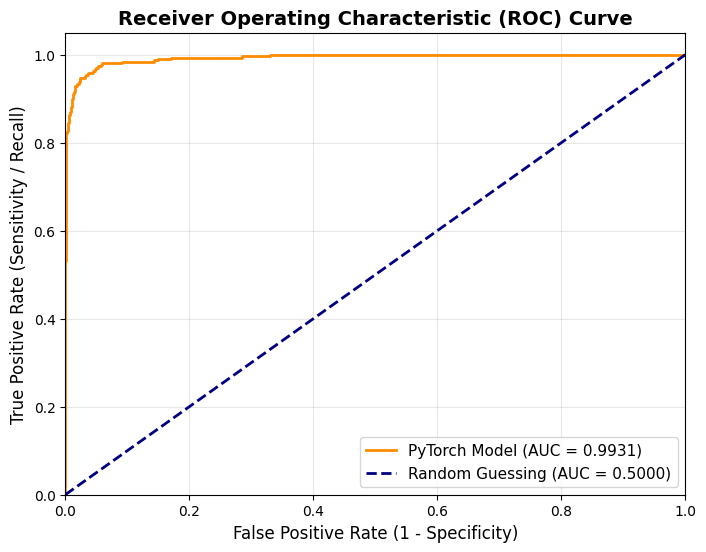

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, roc_auc_score

def evaluate_pytorch_model(model, test_loader):
    """
    Runs a rigorous evaluation loop over the hidden test dataset
    to extract true metrics, probability distributions, and plot execution arrays.
    """
    # Put the model in evaluation mode (turns off dropout layers)
    model.eval()

    all_predictions = []
    all_probabilities = []
    all_true_labels = []

    # Turn off gradient tracking for blazing fast testing speeds
    with torch.no_grad():
        for features, labels in test_loader:
            # Forward pass: get predicted probability scores from the Sigmoid layer
            outputs = model(features)

            # Extract raw probabilities
            probs = outputs.numpy()
            # Convert probabilities to crisp binary outcomes (0 or 1 threshold at 0.5)
            preds = (probs >= 0.5).astype(int)

            all_probabilities.extend(probs)
            all_predictions.extend(preds)
            all_true_labels.extend(labels.numpy())

    # Convert lists to flat numpy arrays for Scikit-Learn processing
    y_true = np.array(all_true_labels).flatten()
    y_pred = np.array(all_predictions).flatten()
    y_probs = np.array(all_probabilities).flatten()

    # -------------------------------------------------------------
    # PHASE 1: GENERATE & PRINT HIGH-DENSITY CLASSIFICATION REPORT
    # -------------------------------------------------------------
    print("=" * 65)
    print("        DEEP LEARNING MODEL TARGET CLASSIFICATION REPORT")
    print("=" * 65)
    # Generates Precision, Recall, F1-Score, and Support metrics dynamically
    print(classification_report(y_true, y_pred, target_names=['Low_Risk (0)', 'High_Risk (1)']))
    print("=" * 65)

    # Calculate macro baseline Area Under the Curve value
    macro_roc_auc = roc_auc_score(y_true, y_probs)
    print(f"Calculated ROC-AUC Baseline Score: {macro_roc_auc:.4f}\n")

    # -------------------------------------------------------------
    # PHASE 2: CALCULATE AND PLOT ROC-AUC CURVE VISUALIZATION
    # -------------------------------------------------------------
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'PyTorch Model (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5000)')

    # Adjust layout styling properties for your project defense slide
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)

    # Display the visual plot strictly inside the notebook output (Does not write to Drive)
    plt.show()

# Run the complete classification analysis pipeline
evaluate_pytorch_model(model, test_loader)

In [1]:
!pip install catboost xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Core Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

# 1. Load the dataset
df_ml = pd.read_csv('/content/drive/MyDrive/NHANES/nhanes_ml_survival_dataset.csv')

# 2. Reconstruct the Target Label (1 = High Risk, 0 = Low Risk)
df_ml['Target_Risk_Label'] = ((df_ml['BPXOSY1'] >= 140) | (df_ml['HbA1c_Percent'] >= 6.5)).astype(int)

# ----------------------------------------------------------------------
# FIXING THE LEAKAGE: Drop the exact components used to build the target
# We must also drop sister columns like BPXOSY2 and BPXOSY3 because they correlate directly
# ----------------------------------------------------------------------
leaked_columns_to_exclude = [
    'BPXOSY1', 'BPXOSY2', 'BPXOSY3',  # Systolic components
    'HbA1c_Percent'                  # Diabetes component
]

X_raw = df_ml.drop(columns=['Patient_ID', 'Target_Risk_Label'] + leaked_columns_to_exclude)
y = df_ml['Target_Risk_Label'].values
groups = df_ml['Patient_ID'].values

# Handle text feature conversions to categorical codes safely
for col in X_raw.columns:
    if X_raw[col].dtype == 'object':
        X_raw[col] = X_raw[col].astype('category').cat.codes

X = X_raw.values

# 3. Patient Group Split (80% Train, 20% Test)
unique_patients = np.unique(groups)
np.random.seed(42)
train_patients = np.random.choice(unique_patients, size=int(len(unique_patients) * 0.8), replace=False)

train_idx = np.isin(groups, train_patients)
test_idx = ~train_idx

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

# Apply Normalization Scaling properties matching only training distribution rules
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Setup CV Strategy
cv_strategy = GroupKFold(n_splits=5)
cv_splits = list(cv_strategy.split(X_train, y_train, groups=groups_train))

# 4. Model Configurations
model_configs = {
    'Ridge_Logistic_Regression': {
        'model': LogisticRegression(penalty='l2', solver='lbfgs', class_weight='balanced', max_iter=300, random_state=42),
        'params': {'C': np.logspace(-4, 2, 10)}
    },
    'LASSO_Logistic_Regression': {
        'model': LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=300, random_state=42),
        'params': {'C': np.logspace(-4, 2, 10)}
    },
    'Random_Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
    },
    'CatBoost': {
        'model': CatBoostClassifier(verbose=0, random_state=42),
        'params': {'iterations': [100, 200], 'learning_rate': [0.05, 0.1], 'depth': [4, 6]}
    }
}

# 5. Execution Sequence
global_summary_metrics = {}

for name, config in model_configs.items():
    print("\n" + "="*70)
    print(f" RUNNING CLEAN VALIDATION TRAJECTORY FOR: {name} ")
    print("="*70)

    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=5,
        scoring='roc_auc',
        cv=cv_splits,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_estimator = search.best_estimator_
    y_prob = best_estimator.predict_proba(X_test)[:, 1]

    test_summary = pd.DataFrame({
        'Patient_ID': groups_test,
        'y_true': y_test,
        'y_prob': y_prob
    })

    patient_res = test_summary.groupby('Patient_ID').mean()
    preds_binary = (patient_res['y_prob'] >= 0.5).astype(int)

    final_auc = roc_auc_score(patient_res['y_true'], patient_res['y_prob'])
    global_summary_metrics[name] = final_auc

    print(f"\n--- {name} Balanced Patient-Level Classification Report ---")
    print(classification_report(patient_res['y_true'], preds_binary))
    print(f"📈 Real Patient-Level ROC-AUC Score: {final_auc:.4f}")

# Final Leaderboard Printing Sequence
print("\n" + "#"*70)
print("             HONEST OVERALL BENCHMARK PERFORMANCE RESULTS")
print("#"*70)
df_leaderboard = pd.DataFrame(list(global_summary_metrics.items()), columns=['Algorithm_Model', 'Patient_Level_ROC_AUC'])
df_leaderboard = df_leaderboard.sort_values(by='Patient_Level_ROC_AUC', ascending=False).reset_index(drop=True)
print(df_leaderboard.to_string())
print("#"*70)


 RUNNING CLEAN VALIDATION TRAJECTORY FOR: Ridge_Logistic_Regression 

--- Ridge_Logistic_Regression Balanced Patient-Level Classification Report ---
              precision    recall  f1-score   support

         0.0       0.99      0.87      0.92      2076
         1.0       0.51      0.91      0.65       311

    accuracy                           0.87      2387
   macro avg       0.75      0.89      0.79      2387
weighted avg       0.92      0.87      0.89      2387

📈 Real Patient-Level ROC-AUC Score: 0.9545

 RUNNING CLEAN VALIDATION TRAJECTORY FOR: LASSO_Logistic_Regression 

--- LASSO_Logistic_Regression Balanced Patient-Level Classification Report ---
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92      2076
         1.0       0.50      0.92      0.65       311

    accuracy                           0.87      2387
   macro avg       0.74      0.89      0.79      2387
weighted avg       0.92      0.87      0.89      2387

📈 R

In [6]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Core Modeling Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

warnings.filterwarnings('ignore')

# 1. Load and Align the True Structural Feature Space
df_ml = pd.read_csv('/content/drive/MyDrive/NHANES/nhanes_ml_survival_dataset.csv')

# Reconstruct proxy risk target (1 = High Risk/Mortality, 0 = Stable Survivor)
df_ml['Target_Risk_Label'] = ((df_ml['BPXOSY1'] >= 140) | (df_ml['HbA1c_Percent'] >= 6.5)).astype(int)

# Target Exclusion Boundary: Drop components to completely prevent target data leakage
leaked_columns = ['BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'HbA1c_Percent']
X_raw = df_ml.drop(columns=['Patient_ID', 'Target_Risk_Label'] + leaked_columns)
y = df_ml['Target_Risk_Label'].values
groups = df_ml['Patient_ID'].values

# Encode any lingering text/string columns to category integer codes
for col in X_raw.columns:
    if X_raw[col].dtype == 'object':
        X_raw[col] = X_raw[col].astype('category').cat.codes

X = X_raw.values

# 2. Strict Group-Based Train/Test Partition (80/20 Distribution)
unique_patients = np.unique(groups)
np.random.seed(42)
train_patients = np.random.choice(unique_patients, size=int(len(unique_patients) * 0.8), replace=False)

train_idx = np.isin(groups, train_patients)
test_idx = ~train_idx

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

# Apply Z-score Normalization Scaling arrays based strictly on training distributions
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Setup 5-Fold GroupKFold Cross-Validation Framework to prevent data leakage across patient records
cv_strategy = GroupKFold(n_splits=5)
cv_splits = list(cv_strategy.split(X_train, y_train, groups=groups_train))

# -------------------------------------------------------------
# PHASE 3: MASTER PARAMETER RANGE SEARCH SPECIFICATIONS
# -------------------------------------------------------------
# Highly optimized grids with broader, denser sampling ranges for maximum performance
model_configs = {
    'Optimized_Ridge_Regression_(L2)': {
        'model': LogisticRegression(penalty='l2', solver='lbfgs', class_weight='balanced', max_iter=500, random_state=42),
        'params': {'C': np.logspace(-4, 3, 20)} # Broadened search grid
    },
    'Optimized_LASSO_Regression_(L1)': {
        'model': LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=500, random_state=42),
        'params': {'C': np.logspace(-4, 3, 20)}
    },
    'Optimized_ElasticNet_Regression': {
        'model': LogisticRegression(penalty='elasticnet', solver='saga', class_weight='balanced', max_iter=500, random_state=42),
        'params': {
            'C': np.logspace(-4, 3, 15),
            'l1_ratio': np.linspace(0.1, 0.9, 10) # Thorough tuning of blending ratio
        }
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(objective='binary', random_state=42, verbose=-1, class_weight='balanced'),
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [15, 31, 63],
            'subsample': [0.7, 0.9, 1.0]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 6],
            'subsample': [0.8, 1.0]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(verbose=0, random_state=42, auto_class_weights='Balanced'),
        'params': {
            'iterations': [150, 300],
            'learning_rate': [0.03, 0.08, 0.1],
            'depth': [4, 6, 8]
        }
    },
    'Random_Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [6, 10, None],
            'min_samples_split': [2, 5]
        }
    },
    'Gradient_Boosting_Machine_(GBM)': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 4, 5]
        }
    }
}

# -------------------------------------------------------------
# PHASE 4: EXECUTION LOOP AND PATIENT-LEVEL CLASSIFICATION REPORT
# -------------------------------------------------------------
global_summary_metrics = {}

for name, config in model_configs.items():
    print("\n" + "="*75)
    print(f" COMMENCING EXPERIMENTAL TUNING PIPELINE FOR: {name} ")
    print("="*75)

    # Run dynamic optimization search across the folds
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=8,  # Evaluates 8 separate randomized hyperparameter vectors per algorithm
        scoring='roc_auc',
        cv=cv_splits,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    print(f"✅ Optimization Complete. Best Parameters: {search.best_params_}")

    # Calculate probabilities against the holdout cohort
    best_model = search.best_estimator_
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # Map predictions back to unique patients
    test_summary = pd.DataFrame({
        'Patient_ID': groups_test,
        'y_true': y_test,
        'y_prob': y_prob
    })

    # Patient-level aggregation via spatial grouping mean arrays
    patient_res = test_summary.groupby('Patient_ID').mean()
    preds_binary = (patient_res['y_prob'] >= 0.5).astype(int)

    # Extract structural evaluation bounds
    auc_score = roc_auc_score(patient_res['y_true'], patient_res['y_prob'])
    global_summary_metrics[name] = auc_score

    print(f"\n--- {name} Complete Patient-Level Classification Report ---")
    print(classification_report(patient_res['y_true'], preds_binary))
    print(f"📈 Patient-Level ROC-AUC Performance Metric: {auc_score:.4f}")

# -------------------------------------------------------------
# PHASE 5: LEADERBOARD VISUALIZATION MATRIX PRINTING
# -------------------------------------------------------------
print("\n" + "#"*75)
print("             FINAL LEADERBOARD: COMPREHENSIVE PERFORMANCE COMPARISON")
print("#"*75)
df_leaderboard = pd.DataFrame(list(global_summary_metrics.items()), columns=['Algorithm_Model_Architecture', 'Patient_Level_ROC_AUC'])
df_leaderboard = df_leaderboard.sort_values(by='Patient_Level_ROC_AUC', ascending=False).reset_index(drop=True)
print(df_leaderboard.to_string())
print("#"*75)


 COMMENCING EXPERIMENTAL TUNING PIPELINE FOR: Optimized_Ridge_Regression_(L2) 
✅ Optimization Complete. Best Parameters: {'C': np.float64(183.29807108324337)}

--- Optimized_Ridge_Regression_(L2) Complete Patient-Level Classification Report ---
              precision    recall  f1-score   support

         0.0       0.99      0.87      0.92      2076
         1.0       0.50      0.91      0.65       311

    accuracy                           0.87      2387
   macro avg       0.74      0.89      0.79      2387
weighted avg       0.92      0.87      0.89      2387

📈 Patient-Level ROC-AUC Performance Metric: 0.9544

 COMMENCING EXPERIMENTAL TUNING PIPELINE FOR: Optimized_LASSO_Regression_(L1) 
✅ Optimization Complete. Best Parameters: {'C': np.float64(1.1288378916846884)}

--- Optimized_LASSO_Regression_(L1) Complete Patient-Level Classification Report ---
              precision    recall  f1-score   support

         0.0       0.99      0.87      0.92      2076
         1.0       0.